<h2> Nauczanie maszynowe/Ćwiczenia5

                                                                                                    13.11.2025 Jadwiga Krząstek

Zagadnienia na dziś:
- Segmentacja obrazów
- Autoenkodery (w tym tworzenie niskowymiaorwych reprezentacji - "tzw. embeddingów" obrazów)

<h4> Zadanie1 (2 pkt): Rozważ dane SegSperm. Zbuduj model do segmentacji obrazu oparty o architekturę U-Net (swobodnie rozbuduj model z ćwiczeń)


<h4>
    
- Wydziel zbiór treningowy/walidacyjny/testowy (monitoruj proces uczenia).
    
- Potestuj różne hiperparametry/topologie sieci.
 
- W razie konieczności (a ta zapewne będzie występować :) rozważ jako funkcje kosztu DICE -> wyżej) lub kombinacje BCE i DICE (z pewnymi wagami) albo jeszcze inne (poszukaj we własnym zakresie)

- Zaprezentuj przykładowe predykcje modelu. To nie jest łatwe zadanie, jeżeli uda się rozpoznać przynajmniej część obiektu to będzie fajnie! :)

- UWAGA: to sie będzie długo liczyć :( W domu można wziąć mniej zdjęć i spróbować na kilku epokach. Całość można uruchomić w pracowni (proszę o wcześniejszy kontakt)

In [2]:
import torchvision
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.optim as optim
import numpy as np

In [4]:
import os
from PIL import Image
import torch
from torchvision import transforms

img_dir = 'SegSperm/train/images'
mask_dir = 'SegSperm/train/GT1_full'

#transformacje — zamiana na tensory i ewentualna normalizacja
img_transform = transforms.Compose([
    transforms.ToTensor(),  # skala 0-1, kształt (C, H, W)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # opcjonalnie, moze pomoc
])

mask_transform = transforms.Compose([
    transforms.ToTensor()  # zamieni maskę 0/255 → 0.0/1.0
])

#wczytuje wszystkie pliki
image_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

images = []
masks = []

for img_name, mask_name in zip(image_files, mask_files):
    # Otwórz obrazy i maski
    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)
    
    image = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')  # maska w odcieniach szarości

    #zastosuj transformacje
    image_tensor = img_transform(image)
    mask_tensor = mask_transform(mask)

    #maska jest binarna (0/1)
    mask_tensor = (mask_tensor > 0.5).float()

    images.append(image_tensor)
    masks.append(mask_tensor)

images = torch.stack(images)  # kształt: (N, 3, H, W)
masks = torch.stack(masks)    # kształt: (N, 1, H, W)

print(images.shape, masks.shape)
print(images[:2])  # przykładowe dane
print(masks[:2])

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1358954496 bytes.

#### Powyższy fragment kodu (zaproponowany na zajęciach) powoduje błąd alokacji pamięci, więc jest potrzebna taka złożona klasa dzieląca pobieranie danych na etapy. **"images = torch.stack(images)"** próbuje utworzyć jeden wielki tensor zawierający wszystkie obrazy i to spowodowało wykorzystanie całego miejsca RAM. Dane będą teraz wczytywane po batchach.
Tylko tak działało pobranie danych i przejście do dalszych etapów zadania.

In [10]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

img_dir = 'SegSperm/train/images'
mask_dir = 'SegSperm/train/GT1_full'

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

mask_transform = transforms.Compose([
    transforms.ToTensor()
])

#
class SegSpermDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_transform=None, mask_transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(img_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.img_transform = img_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        mask_name = self.mask_files[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        if self.img_transform:
            image = self.img_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        mask = (mask > 0.5).float()
        return image, mask

dataset = SegSpermDataset(img_dir, mask_dir, img_transform, mask_transform)

#podział na zbiory
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

#batch size 4
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

Propopzycja całości

Epoch [1/5] Train Loss: 0.5942, Val Loss: 0.5271, Train Dice: 0.0015, Val Dice: 0.0000
Epoch [2/5] Train Loss: 0.5251, Val Loss: 0.5213, Train Dice: 0.0000, Val Dice: 0.0000
Epoch [3/5] Train Loss: 0.5125, Val Loss: 0.4408, Train Dice: 0.0000, Val Dice: 0.0000
Epoch [4/5] Train Loss: 0.3475, Val Loss: 0.2830, Train Dice: 0.3886, Val Dice: 0.5003
Epoch [5/5] Train Loss: 0.2813, Val Loss: 0.2713, Train Dice: 0.5102, Val Dice: 0.5245


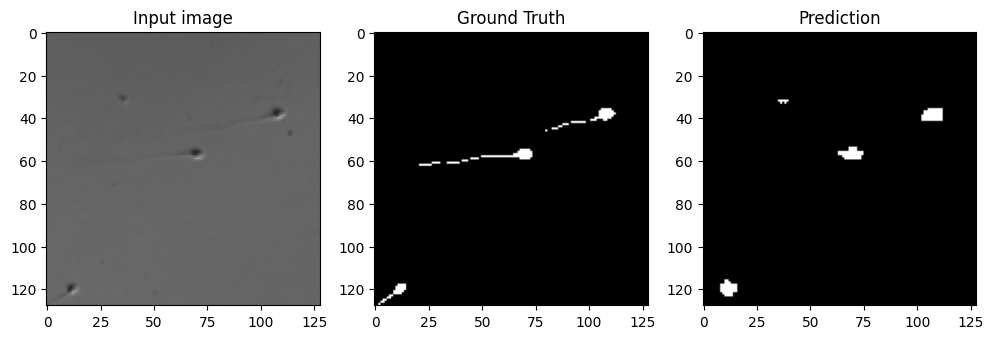

In [15]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class SegSpermDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform_img=None, transform_mask=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)
            mask = (mask > 0.5).float()  # binarna maska

        return image, mask


img_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

mask_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

img_dir = 'SegSperm/train/images'
mask_dir = 'SegSperm/train/GT1_full'

dataset = SegSpermDataset(img_dir, mask_dir, img_transform, mask_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

#definicja modelu
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2, 2)

        self.dec3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x2 = self.enc2(x2)
        x3 = self.pool(x2)
        x3 = self.enc3(x3)
        x = self.dec3(x3)
        x = F.relu(x)
        x = self.dec2(x)
        x = F.relu(x)
        x = torch.sigmoid(self.final(x))
        return x

#funkcje kosztu i miara dokładności
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, inputs, targets):
        bce = self.bce(inputs, targets)
        dice = self.dice(inputs, targets)
        return self.bce_weight * bce + (1 - self.bce_weight) * dice


def dice_coef(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice


def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

#trening
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
train_losses, val_losses = [], []
train_dice, val_dice = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_dice = 0.0, 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_coef(outputs, masks)

    train_losses.append(running_loss / len(train_loader))
    train_dice.append(running_dice / len(train_loader))

    #walidacja
    model.eval()
    val_loss, val_dice_score = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
            val_dice_score += dice_coef(outputs, masks)

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(val_dice_score / len(val_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, "
          f"Train Dice: {train_dice[-1]:.4f}, Val Dice: {val_dice[-1]:.4f}")

model.eval()
sample_img, sample_mask = next(iter(val_loader))
sample_img = sample_img.to(device)
with torch.no_grad():
    pred = model(sample_img)
pred = (pred > 0.5).float().cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img[0].permute(1,2,0).cpu() * 0.5 + 0.5)
axes[0].set_title("Input image")
axes[1].imshow(sample_mask[0,0].cpu(), cmap="gray")
axes[1].set_title("Ground Truth")
axes[2].imshow(pred[0,0], cmap="gray")
axes[2].set_title("Prediction")
plt.show()


#### Model dość dobrze określił jedynie ogólne położenie pojedynczych komórek. Dobrze będzie podjąć próbę stworzenia bardziej złożonego modelu: dwie konwolucje, struktura sieci U-net, funkcja kosztu 0.50\*BCE+0.5\*(1-DICE).

C:\Users\jadwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Urządzenie: cpu


Epoka 1/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [04:10<00:00,  3.30s/it]


[Epoka 1] TrainLoss=0.7138, ValLoss=0.6608, Dice=0.5303


Epoka 2/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [04:19<00:00,  3.41s/it]


...

[Epoka 3] TrainLoss=0.6162, ValLoss=0.6017, Dice=0.6025


Epoka 4/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [03:53<00:00,  3.07s/it]


[Epoka 4] TrainLoss=0.5937, ValLoss=0.5753, Dice=0.6320


Epoka 5/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [03:48<00:00,  3.01s/it]


[Epoka 5] TrainLoss=0.5727, ValLoss=0.5609, Dice=0.6333


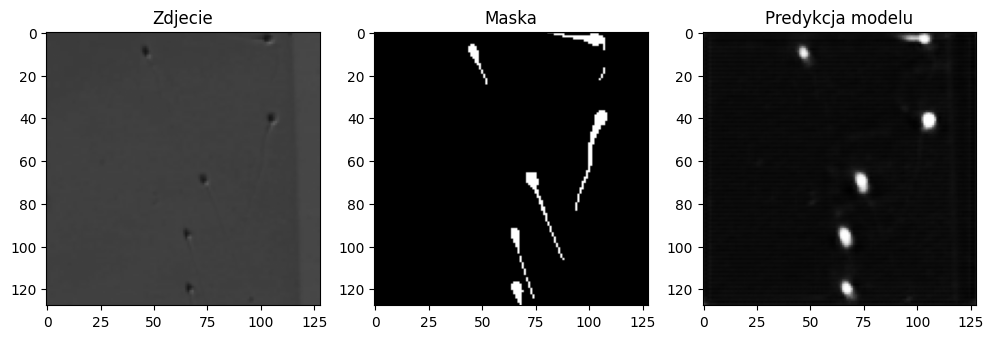

In [1]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

img_dir = 'SegSperm/train/images'
mask_dir = 'SegSperm/train/GT1_full'

img_transform = transforms.Compose([
    transforms.Resize((128, 128)), #dla lepszych wyników można zwiększyć rozmiar do 256, to jednak znacznie wydłuża obliczenia (wynik testów poniżej)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

mask_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

images, masks = [], []

for img_name, mask_name in zip(image_files, mask_files):
    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    image = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')

    img_tensor = img_transform(image)
    mask_tensor = mask_transform(mask)
    mask_tensor = (mask_tensor > 0.5).float()

    images.append(img_tensor)
    masks.append(mask_tensor)

images = torch.stack(images)
masks = torch.stack(masks)

#train/val/test
n_total = len(images)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(images, masks),
    [n_train, n_val, n_test]
)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Urządzenie:", device)

class BCEDiceLoss(nn.Module): #obliczanie funkcji kosztu BCE+DICE (najlepsze wyniki w przypadku ich połączenia 50-50)
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        bce = self.bce(inputs, targets)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 0.5 * bce + 0.5 * (1 - dice)

class DeepUNet(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch): #2×(Conv2D + BatchNorm + ReLU).
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        d4 = self.up4(x5)
        d4 = torch.cat([d4, x4], dim=1) #skip connection, łączenie cech z odpowiadających poziomów enkodera i dekodera
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, x3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, x2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, x1], dim=1)
        d1 = self.dec1(d1)

        out = torch.sigmoid(self.final(d1))
        return out


model = DeepUNet().to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 5

def dice_score(pred, target, smooth=1e-6): 
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

train_losses, val_losses, val_dice = [], [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    #walidacja
    model.eval()
    val_loss, dice_total = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(dice_total / len(val_loader))
    print(f"[Epoka {epoch+1}] TrainLoss={train_losses[-1]:.4f}, ValLoss={val_losses[-1]:.4f}, Dice={val_dice[-1]:.4f}")

model.eval()
sample_img, sample_mask = next(iter(test_loader))
with torch.no_grad():
    pred_mask = model(sample_img.to(device)).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5)
axes[0].set_title('Zdjecie')
axes[1].imshow(sample_mask[0, 0], cmap='gray')
axes[1].set_title('Maska')
axes[2].imshow(pred_mask[0, 0], cmap='gray')
axes[2].set_title('Predykcja modelu')
plt.show()

#### Powyższe predykcje są całkiem dobre. Zostały oznaczone wszystkie pojedyncze główki. Teraz podejmijmy kolejne próby tej samej topologii sieci:

        a) więcej epok uczenia (15) i taki sam rozmiar obrazka (128)
        b) większy rozmiar obrazka (256) i tyle samo epok uczenia (5)
 

#### a) więcej epok uczenia (15) i taki sam rozmiar obrazka (128)

Epoka 1/15: 100%|██████████████████████████████████████████████████████████████████████| 76/76 [22:54<00:00, 18.09s/it]


[Epoka 1] TrainLoss=0.5314, ValLoss=0.5235, Dice=0.7131


Epoka 2/15: 100%|██████████████████████████████████████████████████████████████████| 76/76 [10:06:17<00:00, 478.65s/it]


[Epoka 2] TrainLoss=0.5130, ValLoss=0.5041, Dice=0.7474


Epoka 3/15: 100%|██████████████████████████████████████████████████████████████████████| 76/76 [22:51<00:00, 18.05s/it]


...

[Epoka 13] TrainLoss=0.2703, ValLoss=0.2696, Dice=0.7892


Epoka 14/15: 100%|█████████████████████████████████████████████████████████████████████| 76/76 [15:03<00:00, 11.89s/it]


[Epoka 14] TrainLoss=0.2457, ValLoss=0.2485, Dice=0.8095


Epoka 15/15: 100%|███████████████████████████████████████████████████████████████████| 76/76 [1:24:07<00:00, 66.42s/it]


[Epoka 15] TrainLoss=0.2230, ValLoss=0.2267, Dice=0.8055


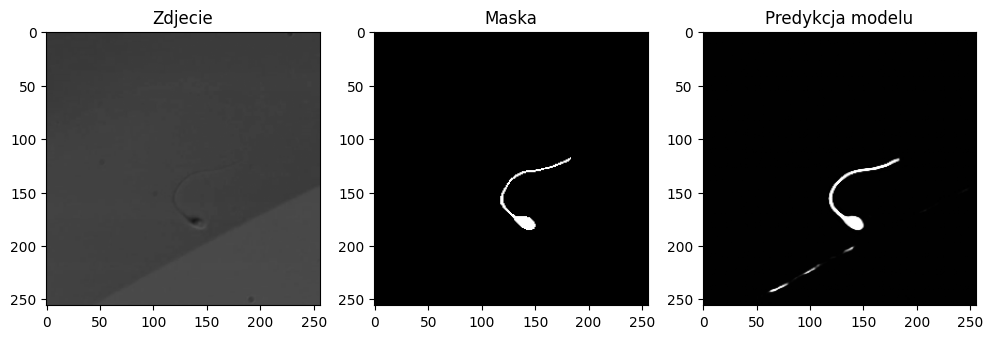

In [4]:
num_epochs = 15

def dice_score(pred, target, smooth=1e-6): 
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

train_losses, val_losses, val_dice = [], [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    #walidacja
    model.eval()
    val_loss, dice_total = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(dice_total / len(val_loader))
    print(f"[Epoka {epoch+1}] TrainLoss={train_losses[-1]:.4f}, ValLoss={val_losses[-1]:.4f}, Dice={val_dice[-1]:.4f}")

model.eval()
sample_img, sample_mask = next(iter(test_loader))
with torch.no_grad():
    pred_mask = model(sample_img.to(device)).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5)
axes[0].set_title('Zdjecie')
axes[1].imshow(sample_mask[0, 0], cmap='gray')
axes[1].set_title('Maska')
axes[2].imshow(pred_mask[0, 0], cmap='gray')
axes[2].set_title('Predykcja modelu')
plt.show()

#### Naprawdę dobra predykcja. Pojawiły się jednak rozpoznane elementy, których nie było na masce.

#### b) większy rozmiar obrazka (256) i tyle samo epok uczenia (5)

Urządzenie: cpu


Epoka 1/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [15:39<00:00, 12.36s/it]


[Epoka 1] TrainLoss=0.6880, ValLoss=0.6361, Dice=0.5552


Epoka 2/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [15:07<00:00, 11.94s/it]


[Epoka 2] TrainLoss=0.6222, ValLoss=0.6002, Dice=0.6322


...

[Epoka 3] TrainLoss=0.5933, ValLoss=0.5759, Dice=0.6798


Epoka 4/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [13:55<00:00, 10.99s/it]


[Epoka 4] TrainLoss=0.5718, ValLoss=0.5591, Dice=0.6846


Epoka 5/5: 100%|███████████████████████████████████████████████████████████████████████| 76/76 [14:29<00:00, 11.44s/it]


[Epoka 5] TrainLoss=0.5512, ValLoss=0.5381, Dice=0.7371


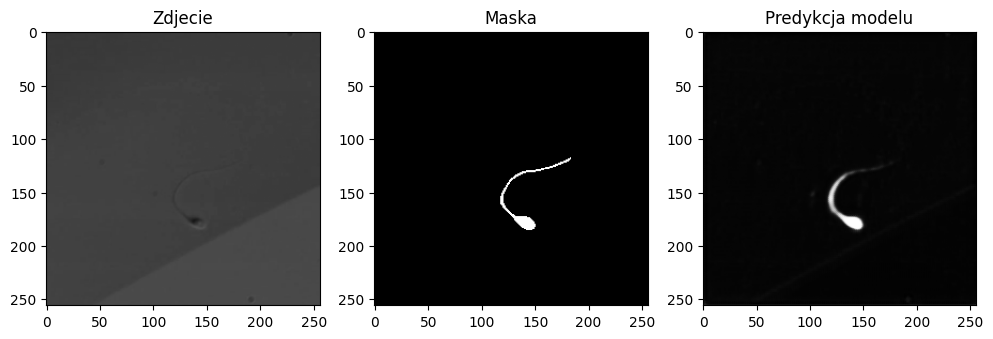

In [3]:
img_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

image_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

images, masks = [], []

for img_name, mask_name in zip(image_files, mask_files):
    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    image = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')

    img_tensor = img_transform(image)
    mask_tensor = mask_transform(mask)
    mask_tensor = (mask_tensor > 0.5).float()  #maska

    images.append(img_tensor)
    masks.append(mask_tensor)

images = torch.stack(images)
masks = torch.stack(masks)

#train/val/test
n_total = len(images)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(images, masks),
    [n_train, n_val, n_test]
)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Urządzenie:", device)

class BCEDiceLoss(nn.Module): #obliczanie funkcji kosztu BCE+DICE (najlepsze wyniki w przypadku ich połączenia 50-50)
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        bce = self.bce(inputs, targets)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 0.5 * bce + 0.5 * (1 - dice)

class DeepUNet(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        d4 = self.up4(x5)
        d4 = torch.cat([d4, x4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, x3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, x2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, x1], dim=1)
        d1 = self.dec1(d1)

        out = torch.sigmoid(self.final(d1))
        return out


model = DeepUNet().to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 5

def dice_score(pred, target, smooth=1e-6): 
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

train_losses, val_losses, val_dice = [], [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    #walidacja
    model.eval()
    val_loss, dice_total = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
            dice_total += dice_score(outputs, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dice.append(dice_total / len(val_loader))
    print(f"[Epoka {epoch+1}] TrainLoss={train_losses[-1]:.4f}, ValLoss={val_losses[-1]:.4f}, Dice={val_dice[-1]:.4f}")

model.eval()
sample_img, sample_mask = next(iter(test_loader))
with torch.no_grad():
    pred_mask = model(sample_img.to(device)).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5)
axes[0].set_title('Zdjecie')
axes[1].imshow(sample_mask[0, 0], cmap='gray')
axes[1].set_title('Maska')
axes[2].imshow(pred_mask[0, 0], cmap='gray')
axes[2].set_title('Predykcja modelu')
plt.show()

#### Ostatnie dwie predykcje - całkiem dobre.


<h4> Zadanie2 (2 pkt.)
    
W ramach zadania należy:
1. Zaimplementować architekturę autoenkodera Wassersteina (enkoder + dekoder). Jako że dataset FMNIST jest trudniejszy, to architektura też powinna być istotnie większa (np. 50 wymiarów przestrzeni ukrytej).
2. Zaimplementować elementy pętli uczenia WAE, w której minimalizujemy koszt $\mathcal{L}_{WAE-MMD}$.
3. Dostosować hiperparametry (learning rate, liczba epok, $C$, $\sigma$, etc.), tak żeby rekonstrukcja i generowane sample wyglądały na poziomie porównywalnym do tych pokazanych poniżej (albo lepiej). Zacznij od $C=1$, $\sigma = 2D$, gdzie $D$ to wymiar przestrzeni ukrytej.

W razie potrzeby można wspomóc się [oryginalną pracą o autoenkoderze Wassersteina](https://arxiv.org/abs/1711.01558) (interesuje nas zwłaszcza strona piąta, Algorytm 2 WAE-MMD) oraz [oficjalnie dostępną implementacją](https://github.com/tolstikhin/wae). 



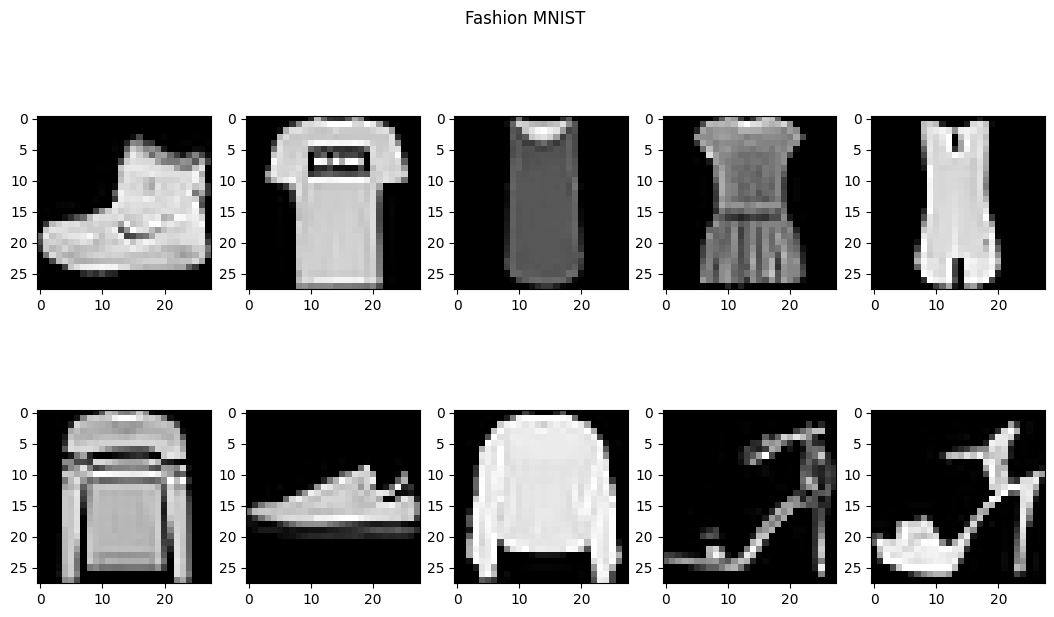

In [3]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor, Lambda, Compose


#dane FashionMNIST 
transforms = Compose([ToTensor(), Lambda(lambda x: x.flatten())])
train_data = FashionMNIST(root='.', 
                   train=True, 
                   transform=transforms,    
                   download=False)

batch_size = 256

# Data Loader
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True) 

_, axes = plt.subplots(2, 5, figsize=(13, 7))
for im, ax in zip(train_data.data[:10], axes.reshape(-1)):
    ax.imshow(im, cmap='gray')
plt.suptitle("Fashion MNIST")
plt.show()

In [9]:
class WAEMMD(nn.Module):
    
    def __init__(self, latent_dim):
        
        super(WAEMMD, self).__init__()
        
        self.latent_dim = latent_dim
        
        D = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, D)
        )

        self.decoder = nn.Sequential(
            nn.Linear(D, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()  
        )
       
    
    def decode(self, encoded):
        return self.decoder(encoded)
    
    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        enc = self.encode(x)
        dec = self.decode(enc)
        return enc, dec
    
    def mmd_loss1(self, y, sigma):
        n = z.size(0)
        z_expand = z.unsqueeze(1)
        z_prior_expand = z_prior.unsqueeze(1)

        #odleglosci
        diff_zz = (z_expand - z.unsqueeze(0)).pow(2).sum(2)
        diff_pp = (z_prior_expand - z_prior.unsqueeze(0)).pow(2).sum(2)
        diff_zp = (z_expand - z_prior.unsqueeze(0)).pow(2).sum(2)

        #kernel
        K_zz = torch.exp(-diff_zz / (2 * sigma**2))
        K_pp = torch.exp(-diff_pp / (2 * sigma**2))
        K_zp = torch.exp(-diff_zp / (2 * sigma**2))

        mmd = K_zz.mean() + K_pp.mean() - 2 * K_zp.mean()
        return mmd

    def mmd_loss(self, y, sigma):
        """Implementacja d_k^2(y,z) z kernela IMQ"""
        n = y.size(0)
        z = torch.randn_like(y)  # próbki z N(0, I)
        
        # obliczamy wszystkie kombinacje odległości (broadcast)
        y_expand = y.unsqueeze(1)  # (n, 1, D)
        z_expand = z.unsqueeze(0)  # (1, n, D)

        # kernel(y, y), kernel(z, z), kernel(y, z)
        yy = ((y_expand - y_expand.transpose(0,1))**2).sum(2)
        zz = ((z_expand - z_expand.transpose(0,1))**2).sum(2)
        yz = ((y_expand - z_expand)**2).sum(2)

        k_y_y = sigma / (sigma + yy)
        k_z_z = sigma / (sigma + zz)
        k_y_z = sigma / (sigma + yz)

        mmd = k_y_y.mean() + k_z_z.mean() - 2 * k_y_z.mean()
        return mmd

Epoch: 0 | train loss: 0.09826


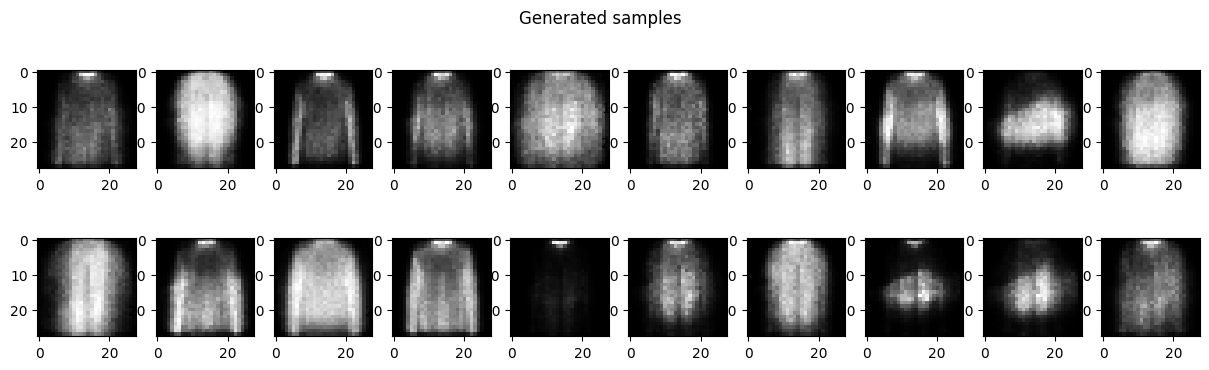

Epoch: 1 | train loss: 0.04701
Epoch: 2 | train loss: 0.03958


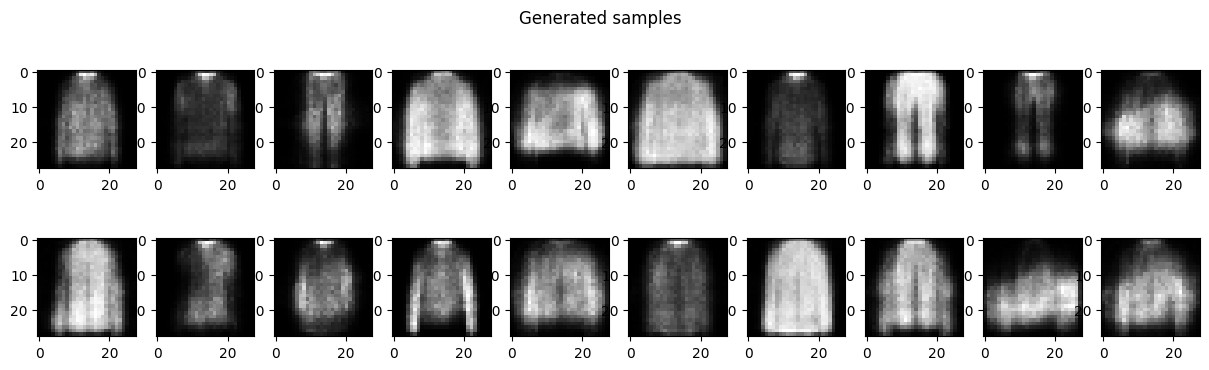

Epoch: 3 | train loss: 0.03445
Epoch: 4 | train loss: 0.03098


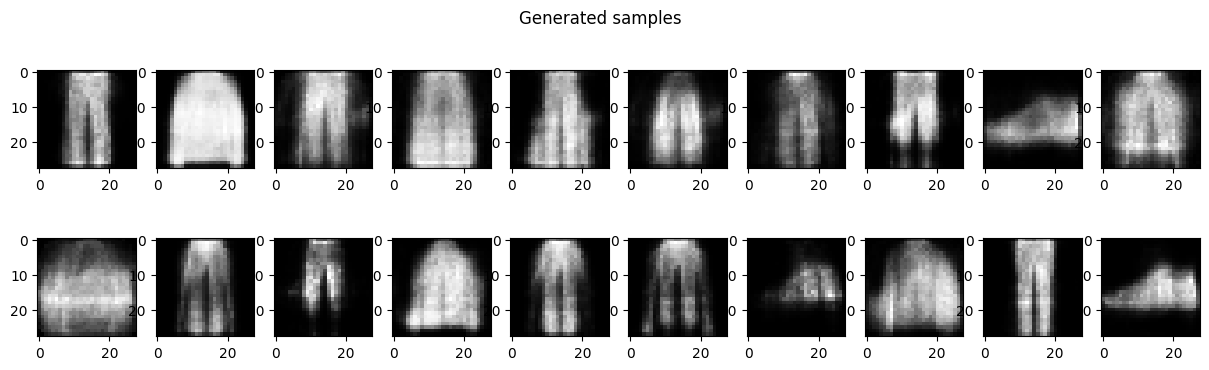

Epoch: 5 | train loss: 0.02901
Epoch: 6 | train loss: 0.02736


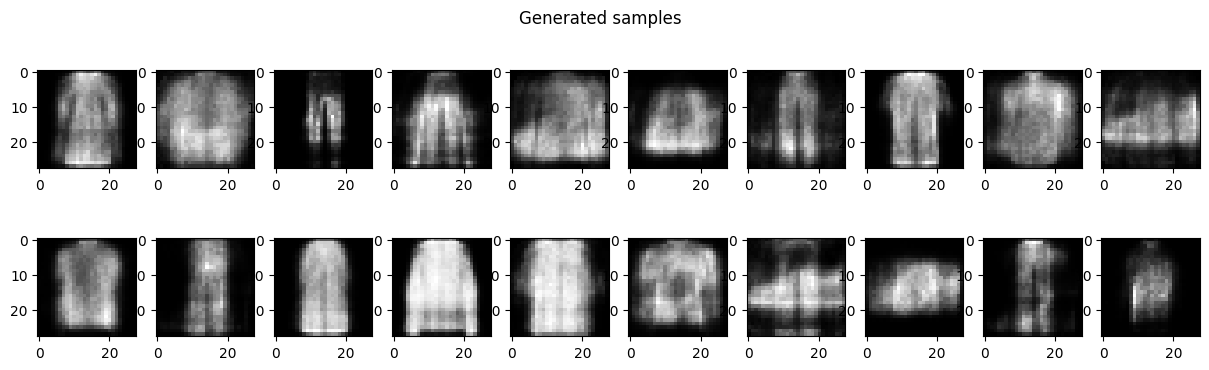

Epoch: 7 | train loss: 0.02611
Epoch: 8 | train loss: 0.02502


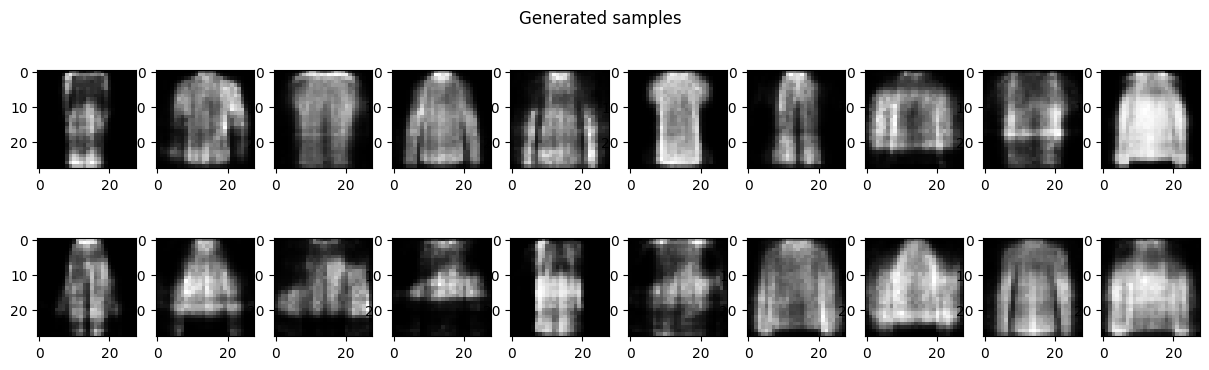

Epoch: 9 | train loss: 0.02419
Epoch: 10 | train loss: 0.02337


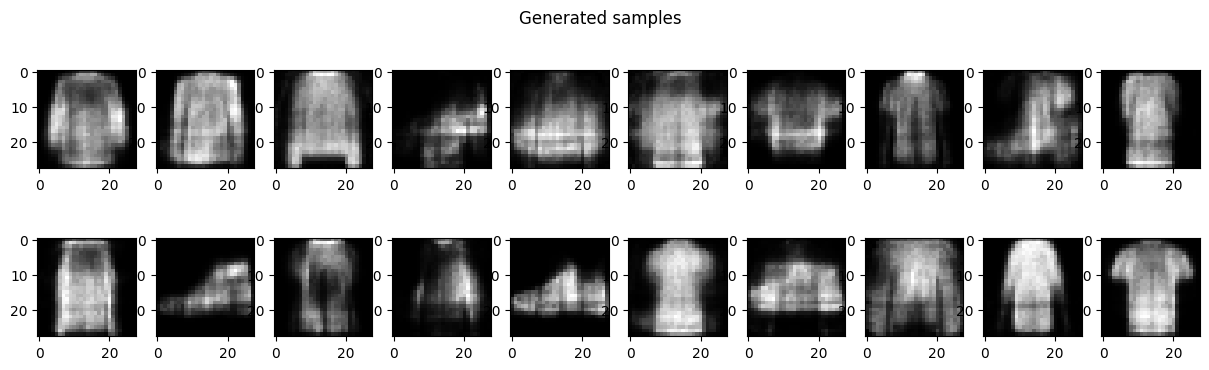

Epoch: 11 | train loss: 0.02263
Epoch: 12 | train loss: 0.02194


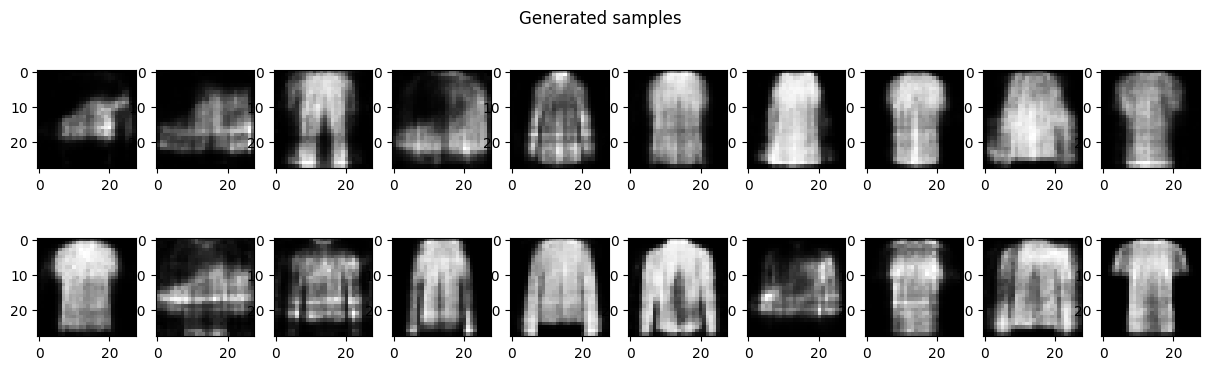

Epoch: 13 | train loss: 0.02150
Epoch: 14 | train loss: 0.02110


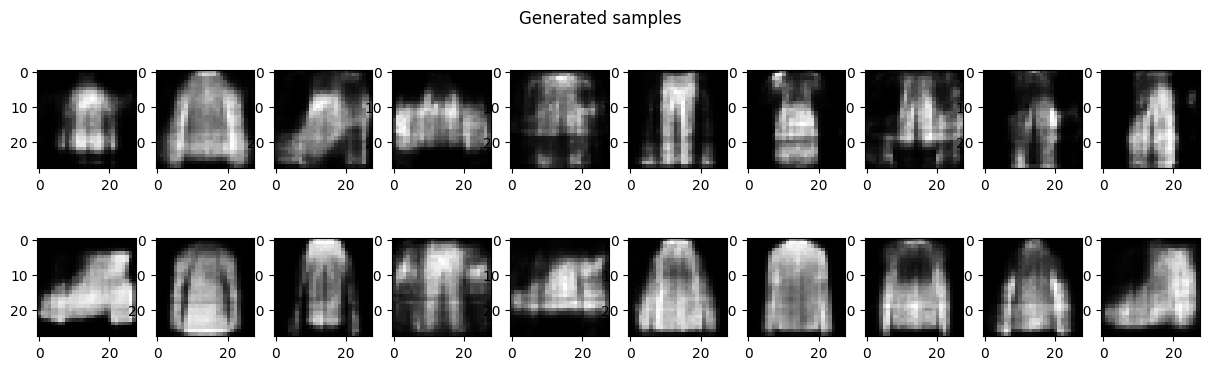

Epoch: 15 | train loss: 0.02051
Epoch: 16 | train loss: 0.02021


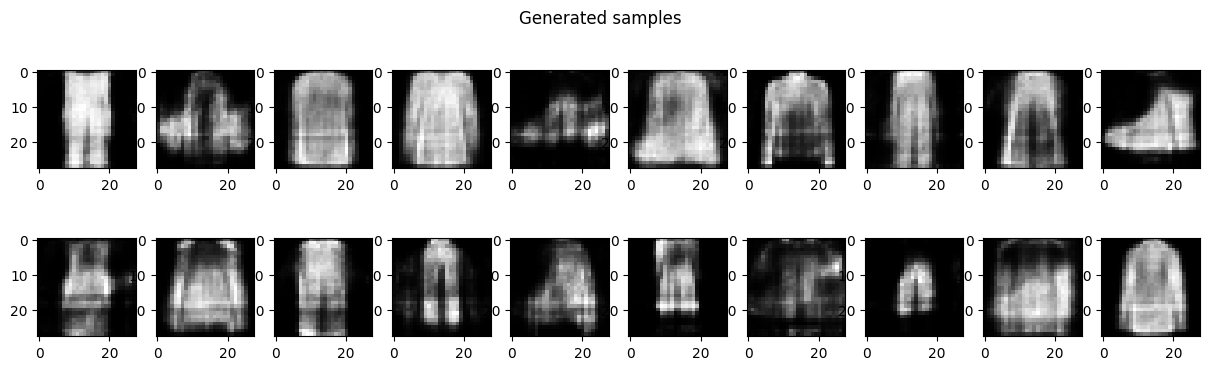

Epoch: 17 | train loss: 0.01981
Epoch: 18 | train loss: 0.01960


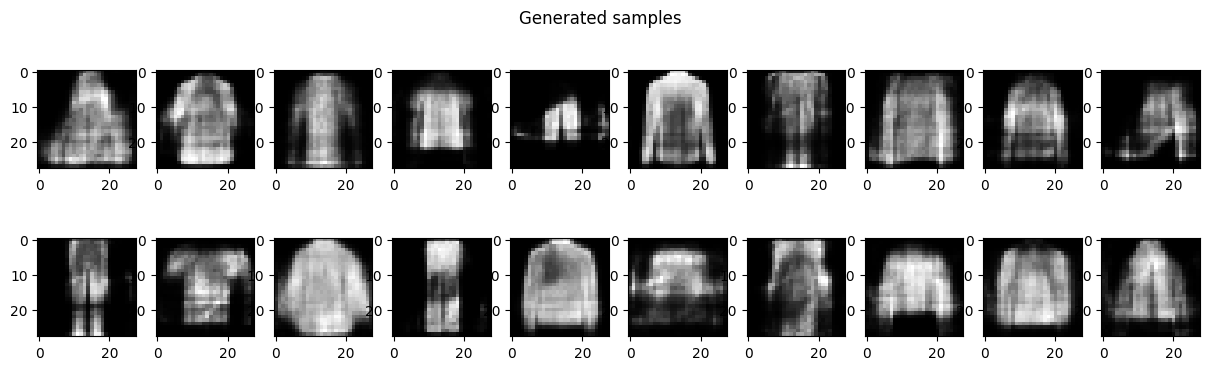

Epoch: 19 | train loss: 0.01927


In [10]:
def plot_samples(model):
    # generowanie wartosci z rozkladu normalnego i przerzucanie przez dekoder
    sampled_z = torch.randn(20, model.latent_dim)
    generated = model.decode(sampled_z)

    #graficzna prezentacja wynikow
    generated = generated.cpu().detach().numpy()
    _, axes = plt.subplots(2, 10, figsize=(15, 4))
    for gen_im, ax in zip(generated, axes.reshape(-1)):
        ax.imshow(gen_im.reshape(28, 28), cmap="gray")
    plt.suptitle("Generated samples")
    plt.show()

# Hiperparametry 
epochs = 20
LR = 0.001
latent_dim = 50 #polecenie
sigma = 100 #2 * latent_dim
C = 1.0 #równowaga pomiędzy marginesem a jakością klasyfikacji


wae = WAEMMD(latent_dim)
optimizer = torch.optim.Adam(wae.parameters(), lr=LR)


rec_loss_fn = torch.nn.MSELoss() #klasysczna funkcja MSE

for epoch in range(epochs):
    epoch_losses = []
    for step, (x, y) in enumerate(train_loader):
        encoded, decoded = wae(x)

        rec_loss_val = rec_loss_fn(decoded, x) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSE
        latent_loss_val = wae.mmd_loss(encoded, sigma) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSD
        loss_val = rec_loss_val + C * latent_loss_val #finalną wartosc funkcji kosztu nalezy wyznaczyc wg odpowiedniego wzoru

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        epoch_losses += [loss_val.item()]

    print(f'Epoch: {epoch} | train loss: {np.mean(epoch_losses):.5f}')

    if epoch % 2 == 0:
        plot_samples(wae)


#### Próba 2. Większy wymiar latencji pozwala na większą pojemność przestrzeni ukrytej, model może lepiej odwzorować skomplikowane cechy obrazów. Dzięki temu możemy uzyskać lepsze rekonstrukcje.

Epoch: 0 | train loss: 0.12058


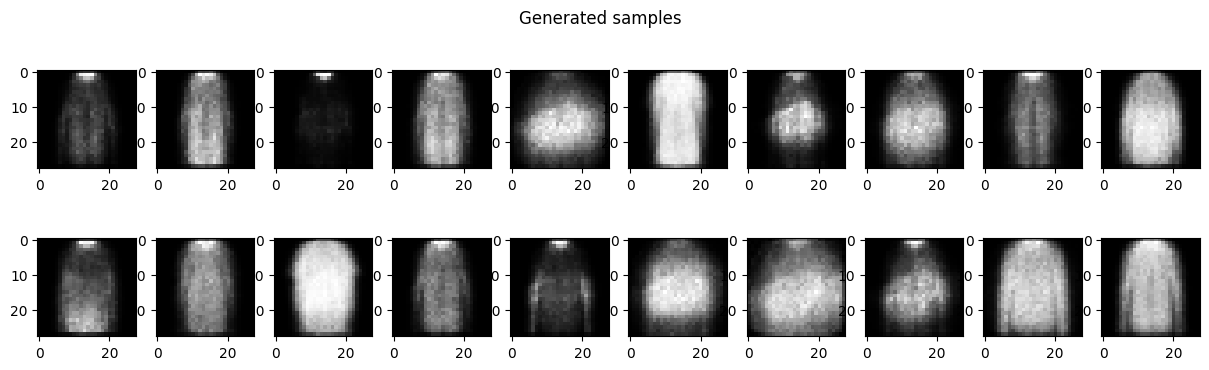

Epoch: 1 | train loss: 0.05756
Epoch: 2 | train loss: 0.04697


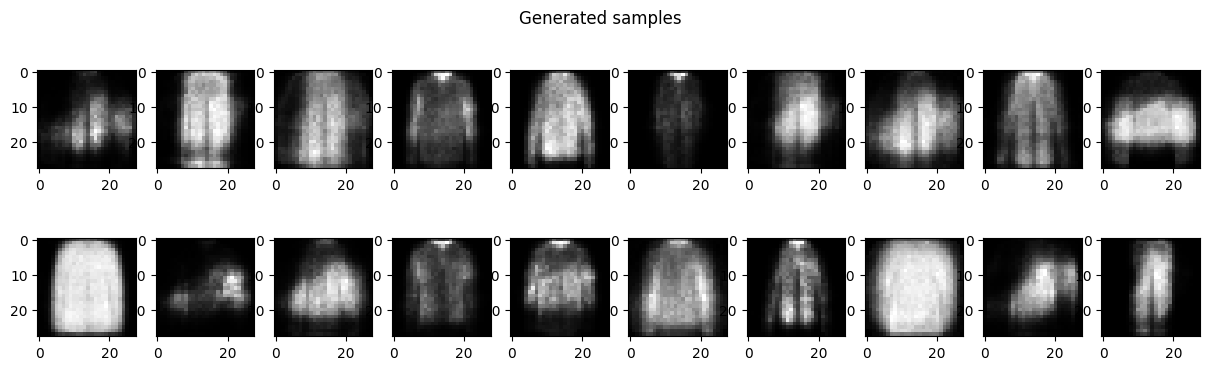

Epoch: 3 | train loss: 0.04018
Epoch: 4 | train loss: 0.03655


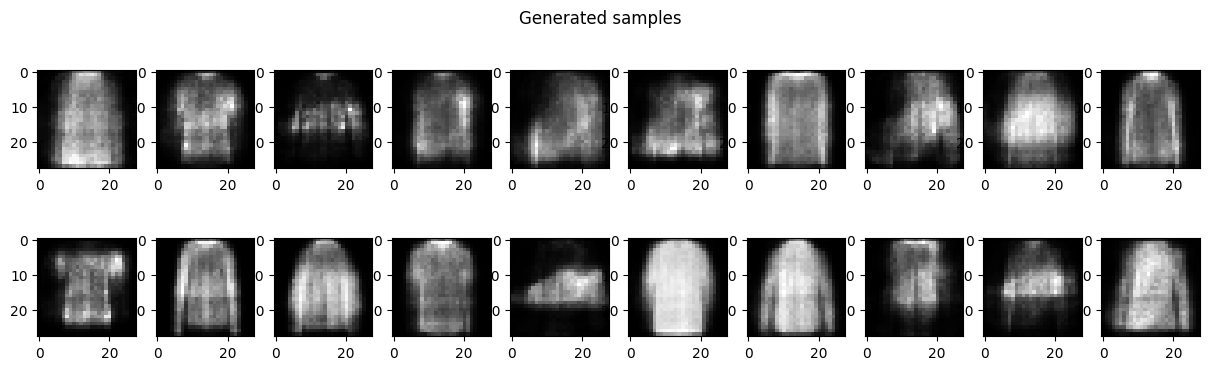

Epoch: 5 | train loss: 0.03370
Epoch: 6 | train loss: 0.03183


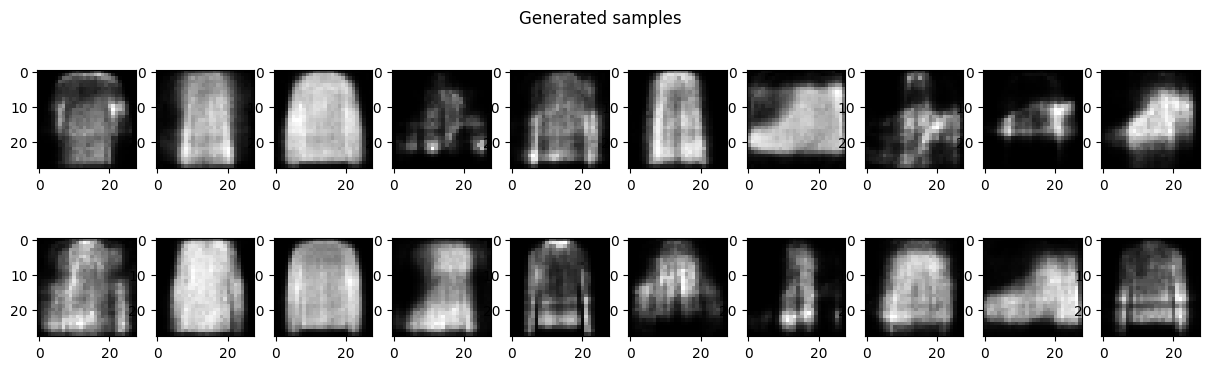

Epoch: 7 | train loss: 0.03033
Epoch: 8 | train loss: 0.02903


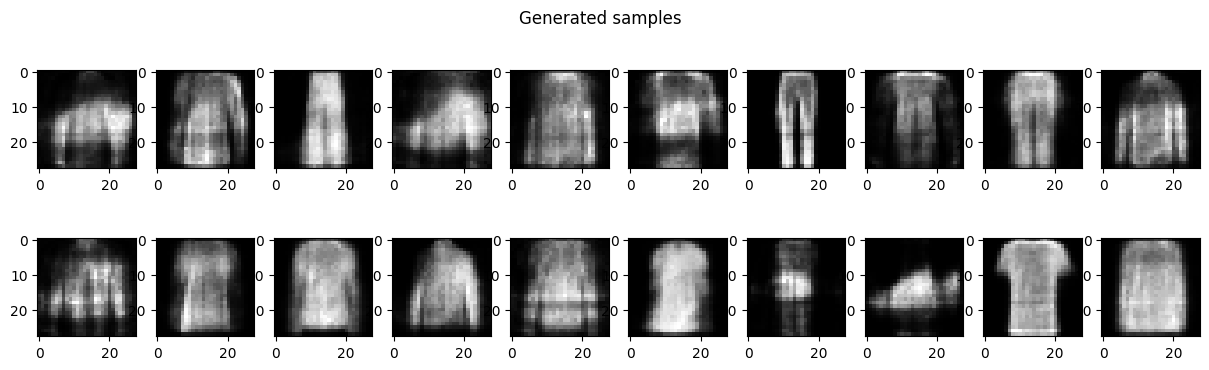

Epoch: 9 | train loss: 0.02804


In [11]:
epochs = 10
LR = 0.001
latent_dim = 80
sigma = 160
C = 1.5 

wae = WAEMMD(latent_dim)
optimizer = torch.optim.Adam(wae.parameters(), lr=LR)


rec_loss_fn = torch.nn.MSELoss() #klasysczna funkcja MSE

for epoch in range(epochs):
    epoch_losses = []
    for step, (x, y) in enumerate(train_loader):
        encoded, decoded = wae(x)

        rec_loss_val = rec_loss_fn(decoded, x) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSE
        latent_loss_val = wae.mmd_loss(encoded, sigma) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSD
        loss_val = rec_loss_val + C * latent_loss_val #finalną wartosc funkcji kosztu nalezy wyznaczyc wg odpowiedniego wzoru

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        epoch_losses += [loss_val.item()]

    print(f'Epoch: {epoch} | train loss: {np.mean(epoch_losses):.5f}')

    if epoch % 2 == 0:
        plot_samples(wae)


#### 10 epok to prawdopowdobnie za mało, dodajmy więcej

Epoch: 0 | train loss: 0.12626


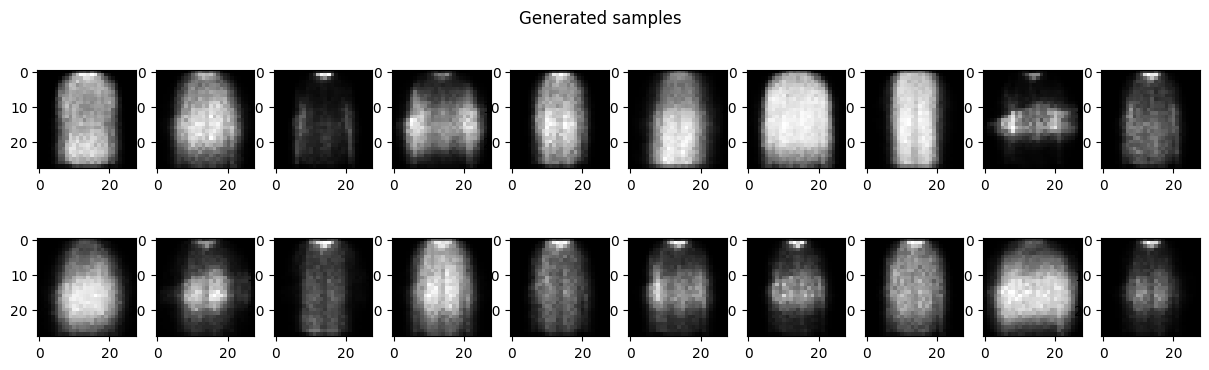

Epoch: 1 | train loss: 0.05927
Epoch: 2 | train loss: 0.04805
Epoch: 3 | train loss: 0.04230
Epoch: 4 | train loss: 0.03854
Epoch: 5 | train loss: 0.03528


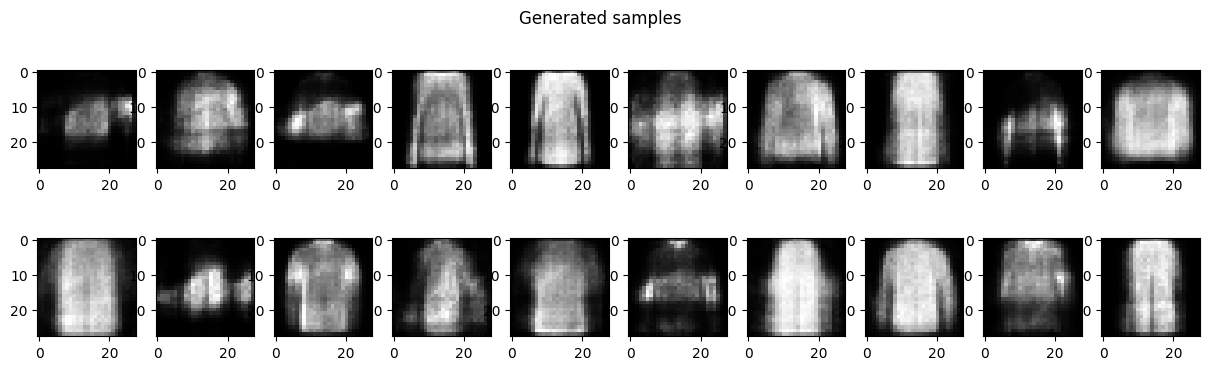

Epoch: 6 | train loss: 0.03322
Epoch: 7 | train loss: 0.03153
Epoch: 8 | train loss: 0.02987
Epoch: 9 | train loss: 0.02901
Epoch: 10 | train loss: 0.02796


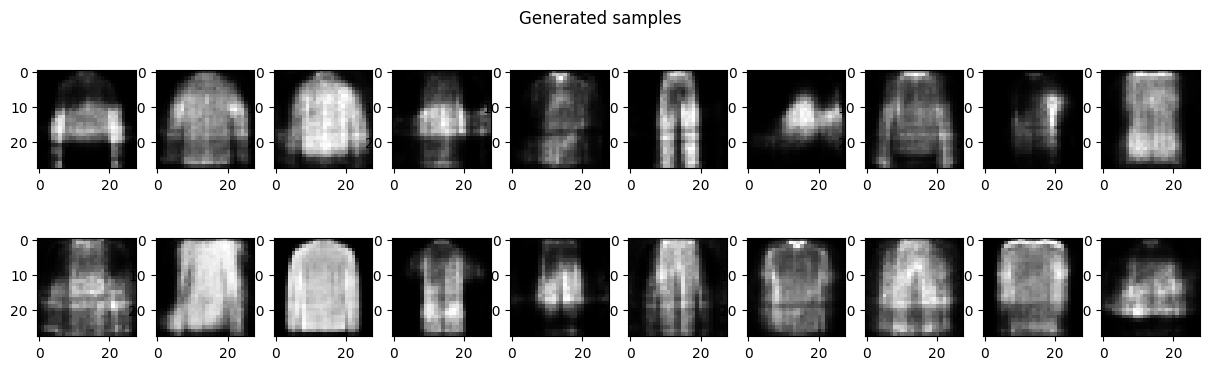

Epoch: 11 | train loss: 0.02706
Epoch: 12 | train loss: 0.02618
Epoch: 13 | train loss: 0.02583
Epoch: 14 | train loss: 0.02517
Epoch: 15 | train loss: 0.02473


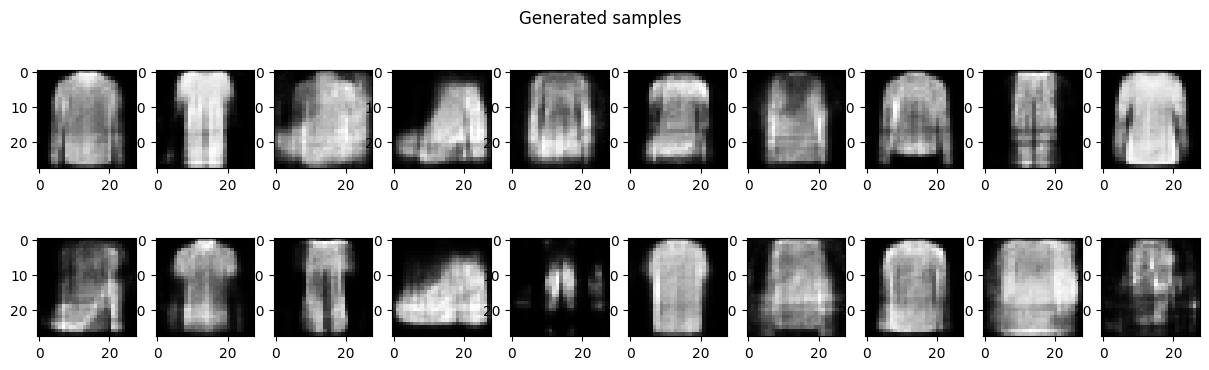

Epoch: 16 | train loss: 0.02408
Epoch: 17 | train loss: 0.02383
Epoch: 18 | train loss: 0.02345
Epoch: 19 | train loss: 0.02309
Epoch: 20 | train loss: 0.02284


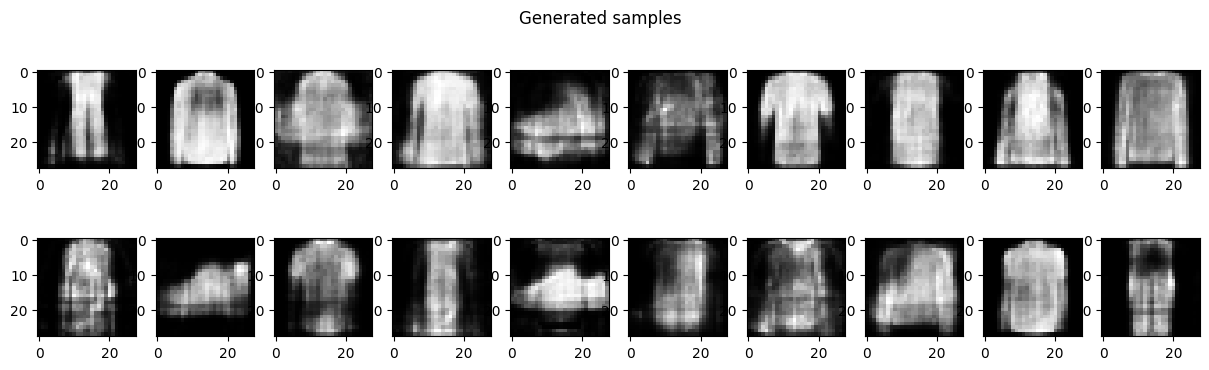

Epoch: 21 | train loss: 0.02246
Epoch: 22 | train loss: 0.02240
Epoch: 23 | train loss: 0.02204
Epoch: 24 | train loss: 0.02178
Epoch: 25 | train loss: 0.02160


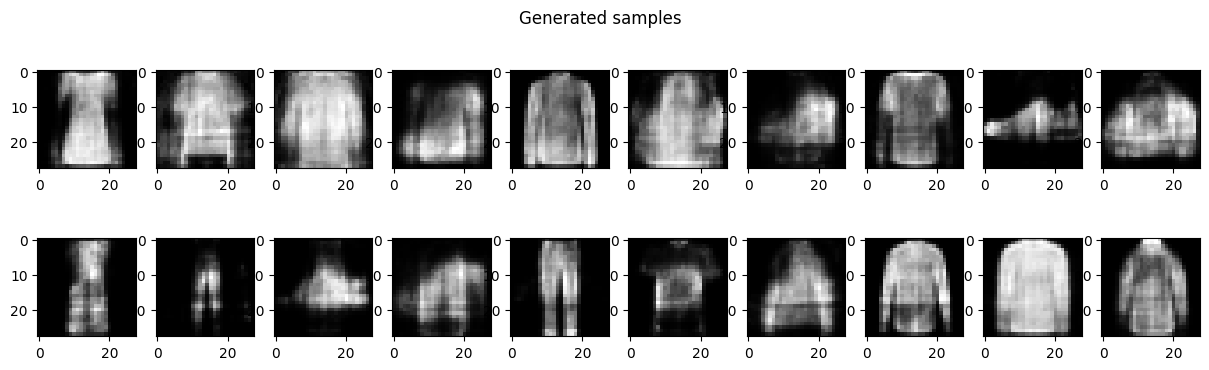

Epoch: 26 | train loss: 0.02141
Epoch: 27 | train loss: 0.02119
Epoch: 28 | train loss: 0.02095
Epoch: 29 | train loss: 0.02090
Epoch: 30 | train loss: 0.02073


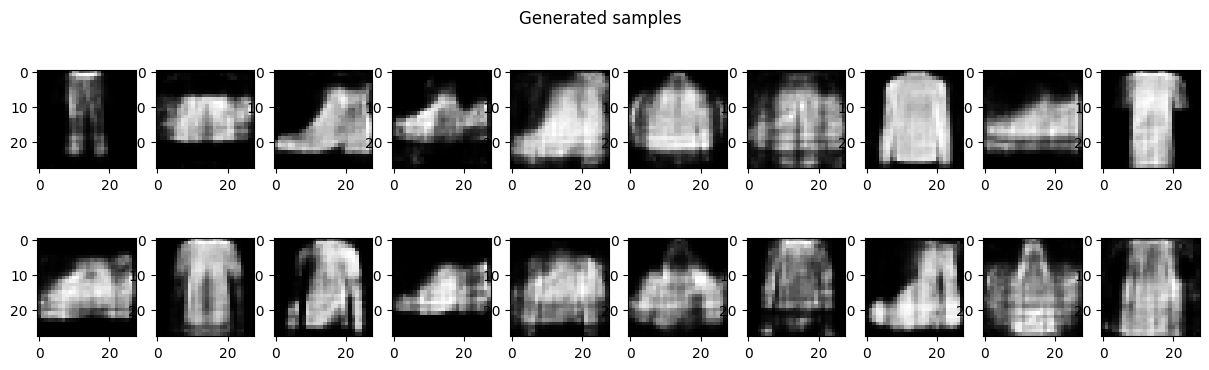

Epoch: 31 | train loss: 0.02069
Epoch: 32 | train loss: 0.02032
Epoch: 33 | train loss: 0.02022
Epoch: 34 | train loss: 0.02018
Epoch: 35 | train loss: 0.02001


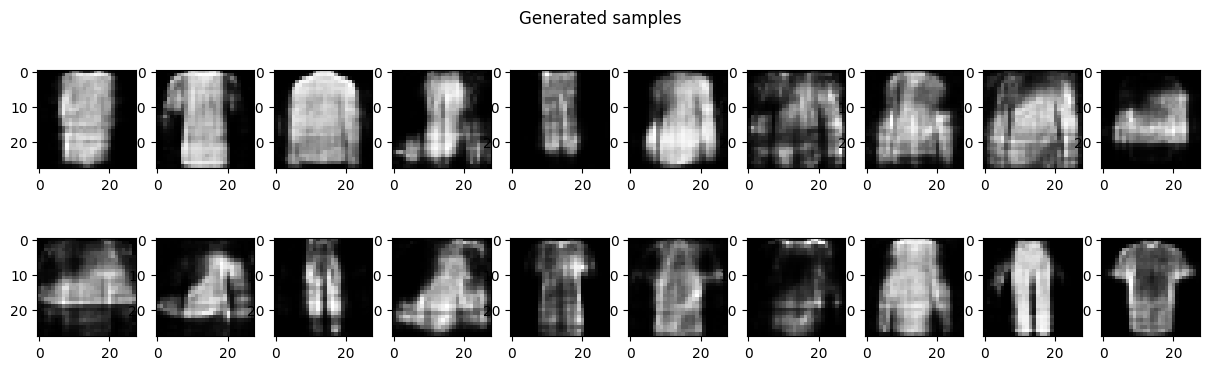

Epoch: 36 | train loss: 0.01980
Epoch: 37 | train loss: 0.01971
Epoch: 38 | train loss: 0.01966
Epoch: 39 | train loss: 0.01945


In [12]:
epochs = 40
LR = 0.001
latent_dim = 80
sigma = 160
C = 1.5 

wae = WAEMMD(latent_dim)
optimizer = torch.optim.Adam(wae.parameters(), lr=LR)


rec_loss_fn = torch.nn.MSELoss() #klasysczna funkcja MSE

for epoch in range(epochs):
    epoch_losses = []
    for step, (x, y) in enumerate(train_loader):
        encoded, decoded = wae(x)

        rec_loss_val = rec_loss_fn(decoded, x) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSE
        latent_loss_val = wae.mmd_loss(encoded, sigma) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSD
        loss_val = rec_loss_val + C * latent_loss_val #finalną wartosc funkcji kosztu nalezy wyznaczyc wg odpowiedniego wzoru

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        epoch_losses += [loss_val.item()]

    print(f'Epoch: {epoch} | train loss: {np.mean(epoch_losses):.5f}')

    if epoch % 5 == 0:
        plot_samples(wae)


#### Duża ilość epok nie dała znacznie lepszych efektów. Teraz dodatkowo zwiększymy wymiar przestrzeni ukrytej.

Epoch: 0 | train loss: 0.12347


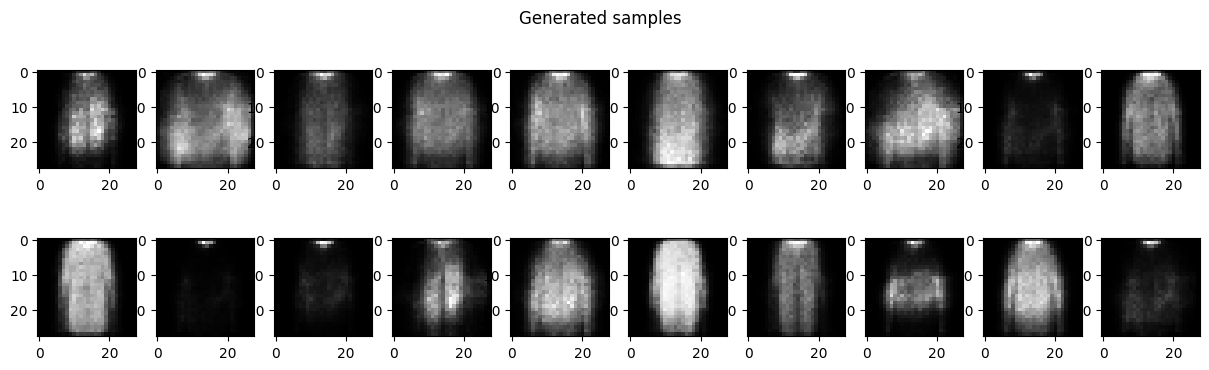

Epoch: 1 | train loss: 0.05699
Epoch: 2 | train loss: 0.04641
Epoch: 3 | train loss: 0.04081
Epoch: 4 | train loss: 0.03724


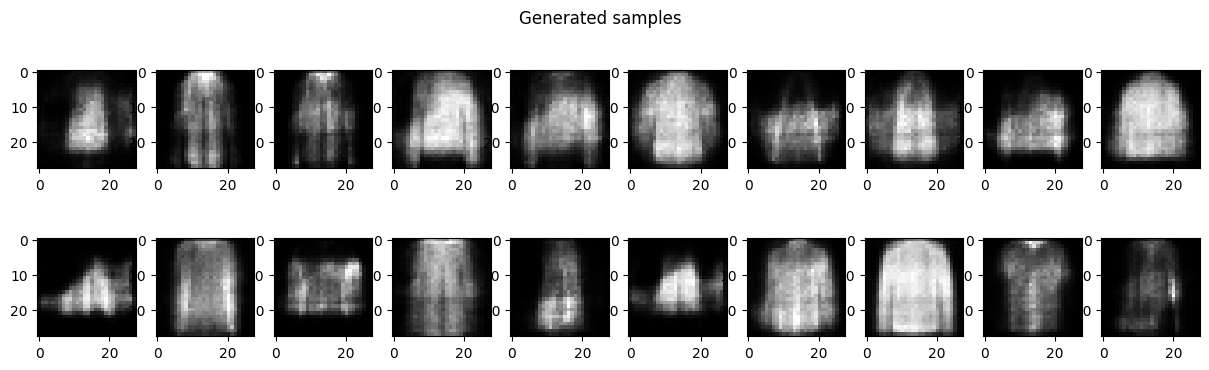

Epoch: 5 | train loss: 0.03415
Epoch: 6 | train loss: 0.03255
Epoch: 7 | train loss: 0.03104
Epoch: 8 | train loss: 0.02975


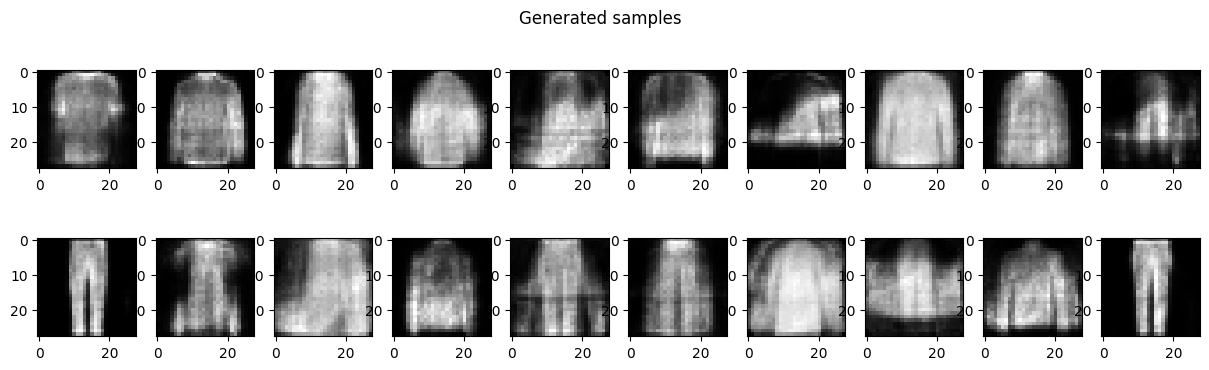

Epoch: 9 | train loss: 0.02888
Epoch: 10 | train loss: 0.02790
Epoch: 11 | train loss: 0.02720
Epoch: 12 | train loss: 0.02668


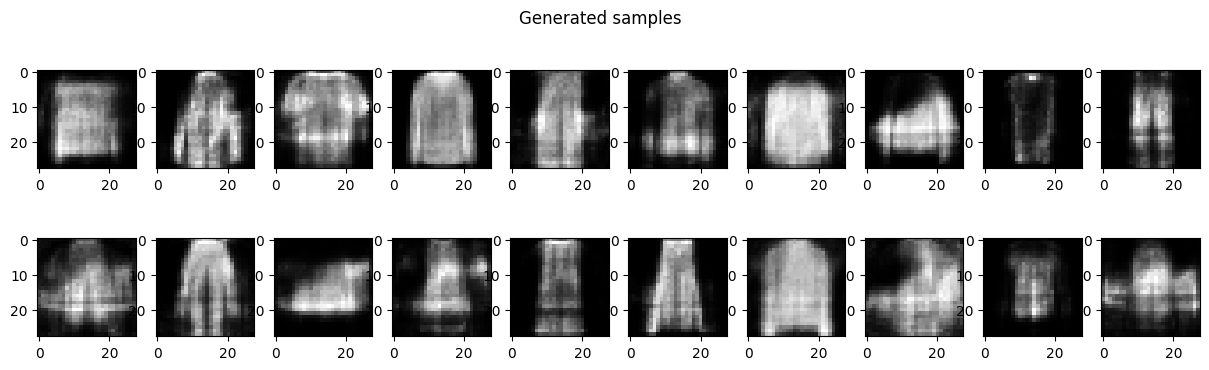

Epoch: 13 | train loss: 0.02602
Epoch: 14 | train loss: 0.02546
Epoch: 15 | train loss: 0.02502
Epoch: 16 | train loss: 0.02457


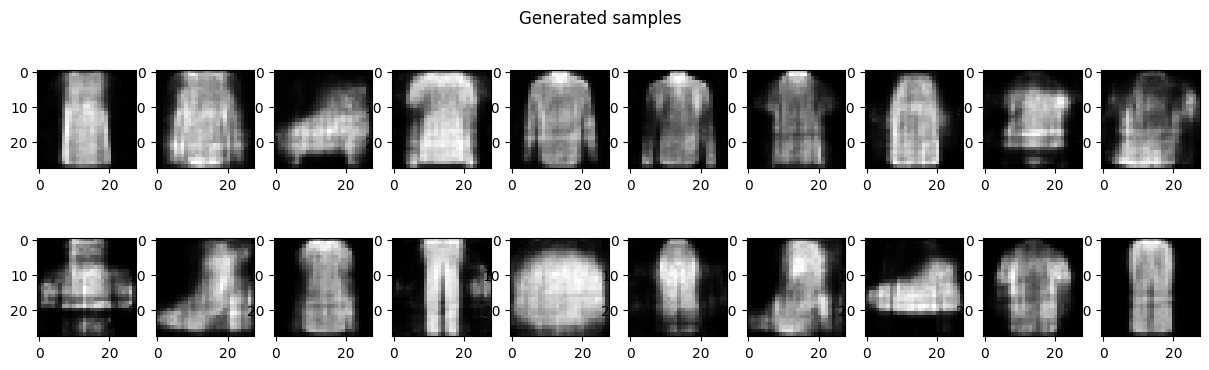

Epoch: 17 | train loss: 0.02423
Epoch: 18 | train loss: 0.02382
Epoch: 19 | train loss: 0.02346


In [13]:
epochs = 20
LR = 0.001
latent_dim = 120
sigma = 200
C = 1.5 

wae = WAEMMD(latent_dim)
optimizer = torch.optim.Adam(wae.parameters(), lr=LR)


rec_loss_fn = torch.nn.MSELoss() #klasysczna funkcja MSE

for epoch in range(epochs):
    epoch_losses = []
    for step, (x, y) in enumerate(train_loader):
        encoded, decoded = wae(x)

        rec_loss_val = rec_loss_fn(decoded, x) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSE
        latent_loss_val = wae.mmd_loss(encoded, sigma) #nalezy wyznaczyc i zapisac do zmiennej wartosc funkcji kosztu MSD
        loss_val = rec_loss_val + C * latent_loss_val #finalną wartosc funkcji kosztu nalezy wyznaczyc wg odpowiedniego wzoru

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        epoch_losses += [loss_val.item()]

    print(f'Epoch: {epoch} | train loss: {np.mean(epoch_losses):.5f}')

    if epoch % 4 == 0:
        plot_samples(wae)


#### Wyniki dość dobre. Ostatecznie model nauczył się generować kształty podobne do butów. Są też rozpoznawalne elementy koszul i spodni.